# RSNA Knee MRI — 标签分布与序列 EDA

> **目标**：在下载任何 DICOM 之前，仅用 CSV 元数据分析标签分布和序列组成，为 Mini 数据集构建提供决策依据。
>
> **环境**：conda `d2l`（PyTorch 2.12 + pandas + sklearn）
> **数据**：`data/metadata/train.csv`、`data/metadata/train_series.csv`
> **评估指标**：macro-averaged AUC ROC（12 个目标）


## 0. 导入与设置


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

SEED = 2026
np.random.seed(SEED)

# Notebook 位于 notebooks/ 下，数据在 ../data/
DATA_DIR = Path('../data/metadata')
TRAIN_CSV = DATA_DIR / 'train.csv'
SERIES_CSV = DATA_DIR / 'train_series.csv'
OUTPUT_DIR = Path('../outputs')
PROCESSED_DIR = Path('../data/processed')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'train.csv exists: {TRAIN_CSV.exists()}')
print(f'train_series.csv exists: {SERIES_CSV.exists()}')


train.csv exists: True
train_series.csv exists: True


## 1. 加载数据


In [28]:
train = pd.read_csv(TRAIN_CSV)
print(f'train.csv: {train.shape[0]} exams, {train.shape[1]} columns')
print(f'Columns: {list(train.columns)}')
train.head(3)


train.csv: 4407 exams, 14 columns
Columns: ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
series = pd.read_csv(SERIES_CSV)
print(f'train_series.csv: {series.shape[0]} series, {series.shape[1]} columns')
print(f'Columns: {list(series.columns)}')
series.head(3)


train_series.csv: 24371 series, 5 columns
Columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal


In [30]:
# 数据完整性检查
train_studies = set(train['StudyInstanceUID'])
series_studies = set(series['StudyInstanceUID'])

in_both = train_studies & series_studies
only_train = train_studies - series_studies
only_series = series_studies - train_studies

print(f'有序列映射的 exam: {len(in_both)}')
print(f'无序列映射的 exam: {len(only_train)}')
print(f'无对应 exam 的序列: {len(only_series)}')

# 将序列汇总合并到 train
series_counts = series.groupby('StudyInstanceUID').agg(
    n_series=('SeriesInstanceUID', 'nunique'),
    n_fluid_sensitive=('Fluid_Sensitive', 'sum'),
    n_fat_suppression=('Fat_Suppression', 'sum'),
    planes=('Anatomical_Plane', lambda x: ','.join(sorted(x.unique())))
).reset_index()

train = train.merge(series_counts, on='StudyInstanceUID', how='left')
print(f'序列信息已合并到 train 表')
print(f'有序列信息的 exam: {train["n_series"].notna().sum()}')
print(f'无序列信息的 exam: {train["n_series"].isna().sum()}')


有序列映射的 exam: 4407
无序列映射的 exam: 0
无对应 exam 的序列: 0
序列信息已合并到 train 表
有序列信息的 exam: 4407
无序列信息的 exam: 0


## 2. 标签定义与清洗


In [31]:
# 12 个目标标签（来自 competition page / sample_submission.csv）
TARGET_COLS = [
    'ACL', 'MCL',
    'Medial Meniscus', 'Lateral Meniscus',
    'Medial OA', 'Lateral OA', 'PF OA',
    'Effusion', 'Synovitis', "Baker's",
    'Contusion', 'Fracture'
]

# 转为数值（空字符串 = 缺失 = 无异常）
for col in TARGET_COLS:
    train[col] = pd.to_numeric(train[col], errors='coerce').fillna(0).astype(int)

# 验证全是 0/1
for col in TARGET_COLS:
    vals = train[col].unique()
    if not set(vals).issubset({0, 1}):
        print(f'!! {col} has non-binary values: {vals[:10]}')
print('标签清洗完成')


标签清洗完成


## 3. 分析一：单标签正样本率

> **对 Mini 集构建最重要。** Macro AUC 意味着每个标签权重均等。
> 如果某个标签正样本太少，Mini 集将无法对其做有意义的评估。
>
> 全部 12 个标签正样本率均 < 1%——医学影像竞赛中典型的极端类别不平衡。


In [32]:
# 每个标签的正样本数和比例
label_stats = pd.DataFrame({
    'n_pos': train[TARGET_COLS].sum(),
    'prevalence_pct': (train[TARGET_COLS].mean() * 100).round(2),
    'n_neg': (1 - train[TARGET_COLS]).sum(),
}).sort_values('prevalence_pct', ascending=False)

# 按相对罕见度分档（全部 < 1%，所以用窄区间）
label_stats['rarity_tier'] = label_stats['prevalence_pct'].apply(
    lambda x: '极低 (<0.3%)' if x < 0.3
    else ('很低 (0.3-0.6%)' if x < 0.6
          else ('偏低 (0.6-1.0%)' if x < 1.0
                else '中等 (>1.0%)'))
)

print(f'总 exam 数: {len(train)}')
print()
label_stats


总 exam 数: 4407



,n_pos,prevalence_pct,n_neg,rarity_tier
Effusion,35,0.79,4372,偏低 (0.6-1.0%)
Synovitis,27,0.61,4380,偏低 (0.6-1.0%)
Medial Meniscus,26,0.59,4381,很低 (0.3-0.6%)
ACL,24,0.54,4383,很低 (0.3-0.6%)
Lateral Meniscus,23,0.52,4384,很低 (0.3-0.6%)
PF OA,21,0.48,4386,很低 (0.3-0.6%)
Contusion,19,0.43,4388,很低 (0.3-0.6%)
Fracture,18,0.41,4389,很低 (0.3-0.6%)
Medial OA,15,0.34,4392,很低 (0.3-0.6%)
Baker's,12,0.27,4395,极低 (<0.3%)


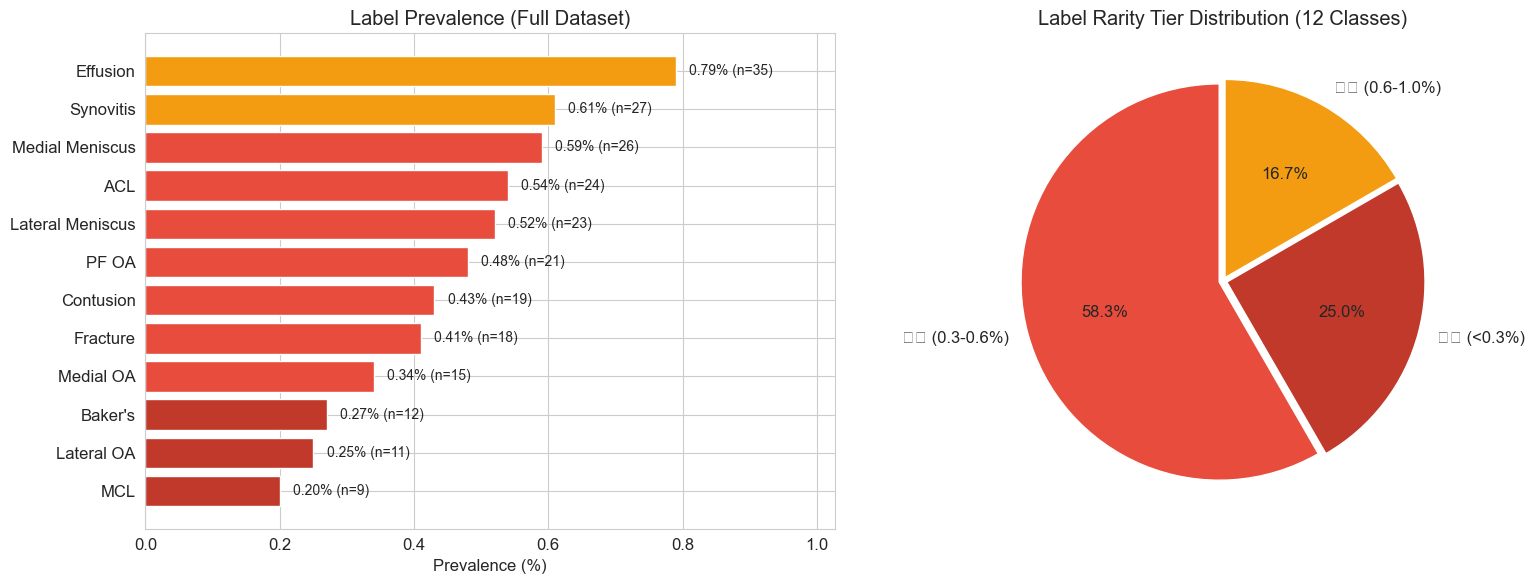

In [33]:
# 可视化：标签正样本率（图表用英文，避免字体问题）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左：正样本率水平柱状图
ax = axes[0]
colors = [
    '#c0392b' if v < 0.3 else '#e74c3c' if v < 0.6
    else '#f39c12' if v < 1.0 else '#27ae60'
    for v in label_stats['prevalence_pct']
]
ax.barh(range(len(label_stats)), label_stats['prevalence_pct'],
        color=colors, edgecolor='white')
ax.set_yticks(range(len(label_stats)))
ax.set_yticklabels(label_stats.index)
ax.set_xlabel('Prevalence (%)')
ax.set_title('Label Prevalence (Full Dataset)')
ax.invert_yaxis()
for i, (v, c) in enumerate(zip(label_stats['prevalence_pct'],
                                label_stats['n_pos'])):
    ax.text(v + 0.02, i, f'{v:.2f}% (n={int(c)})', va='center', fontsize=10)
ax.set_xlim(0, max(label_stats['prevalence_pct']) * 1.3)

# 右：罕见度分档饼图
ax = axes[1]
tier_counts = label_stats['rarity_tier'].value_counts()
tier_colors = {
    '极低 (<0.3%)': '#c0392b',
    '很低 (0.3-0.6%)': '#e74c3c',
    '偏低 (0.6-1.0%)': '#f39c12',
    '中等 (>1.0%)': '#27ae60'
}
ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    colors=[tier_colors.get(l, '#95a5a6') for l in tier_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02] * len(tier_counts)
)
ax.set_title('Label Rarity Tier Distribution (12 Classes)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 关键发现：极端类别不平衡

所有 12 个标签的正样本率均 < 1%。这在医学影像竞赛中很常见——绝大多数膝盖 MRI 是正常的。

这对 Mini 集构建意味着：

- **不能靠随机抽样**：在 350 例随机样本中，MCL（仅 9 个正样本）的期望正样本数不到 1 例
- **必须全量纳入正样本**：所有至少带有一种异常的 exam 都应进入 Mini 集
- **策略**："正样本全集 + 正常样本补足"
- **本地验证的局限**：Mini 集的 per-class AUC 会因正样本太少而非常不稳定；Mini 集的主要用途是**管线验证**而非模型调优


## 4. 分析二：多标签分布

> 了解每个 exam 有多少个异常标签，以及完全正常 vs. 有异常的比例。


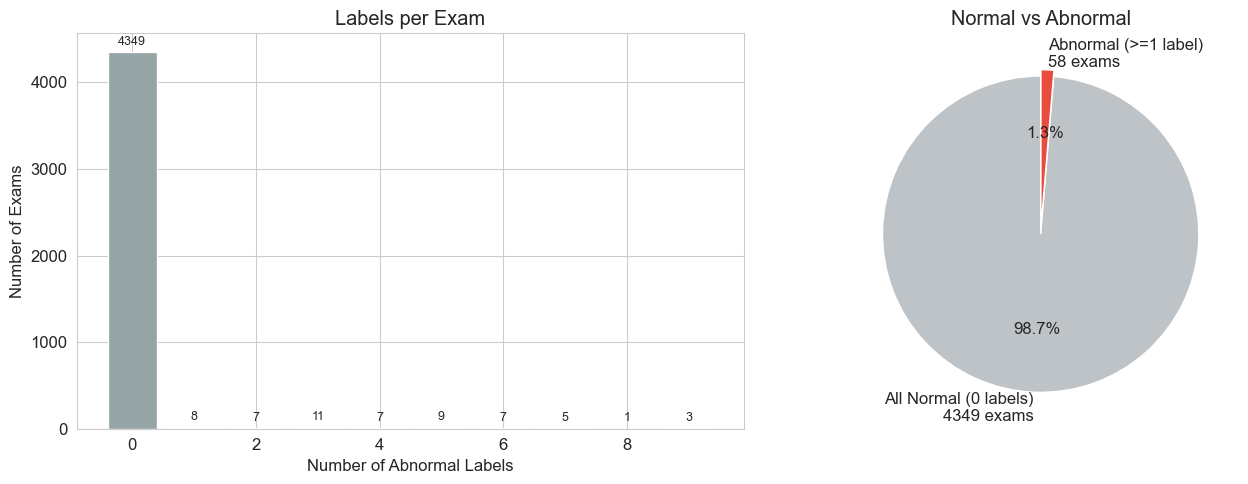

完全正常: 4349 (98.7%)
有异常:   58 (1.3%)
平均标签数（全量）:     0.05
平均标签数（仅异常）:   4.14


In [34]:
train['n_labels'] = train[TARGET_COLS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：每个 exam 的标签数量分布
ax = axes[0]
count_dist = train['n_labels'].value_counts().sort_index()
ax.bar(count_dist.index, count_dist.values,
       color=['#27ae60' if i > 0 else '#95a5a6' for i in count_dist.index],
       edgecolor='white')
ax.set_xlabel('Number of Abnormal Labels')
ax.set_ylabel('Number of Exams')
ax.set_title('Labels per Exam')
for k, v in zip(count_dist.index, count_dist.values):
    ax.text(k, v + max(count_dist.values) * 0.02, str(v), ha='center', fontsize=9)

# 右：正常 vs 异常
ax = axes[1]
n_normal = (train['n_labels'] == 0).sum()
n_abnormal = (train['n_labels'] > 0).sum()
ax.pie(
    [n_normal, n_abnormal],
    labels=[f'All Normal (0 labels)\n{n_normal} exams',
            f'Abnormal (>=1 label)\n{n_abnormal} exams'],
    colors=['#bdc3c7', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.02)
)
ax.set_title('Normal vs Abnormal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_multilabel_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'完全正常: {n_normal} ({n_normal/len(train)*100:.1f}%)')
print(f'有异常:   {n_abnormal} ({n_abnormal/len(train)*100:.1f}%)')
print(f'平均标签数（全量）:     {train["n_labels"].mean():.2f}')
print(f'平均标签数（仅异常）:   '
      f'{train.loc[train["n_labels"]>0, "n_labels"].mean():.2f}')


## 5. 分析三：标签共现矩阵

> 单元格 (i, j) 表示 P(label_j = 1 | label_i = 1)——已知标签 i 为阳性时，标签 j 也为阳性的概率。


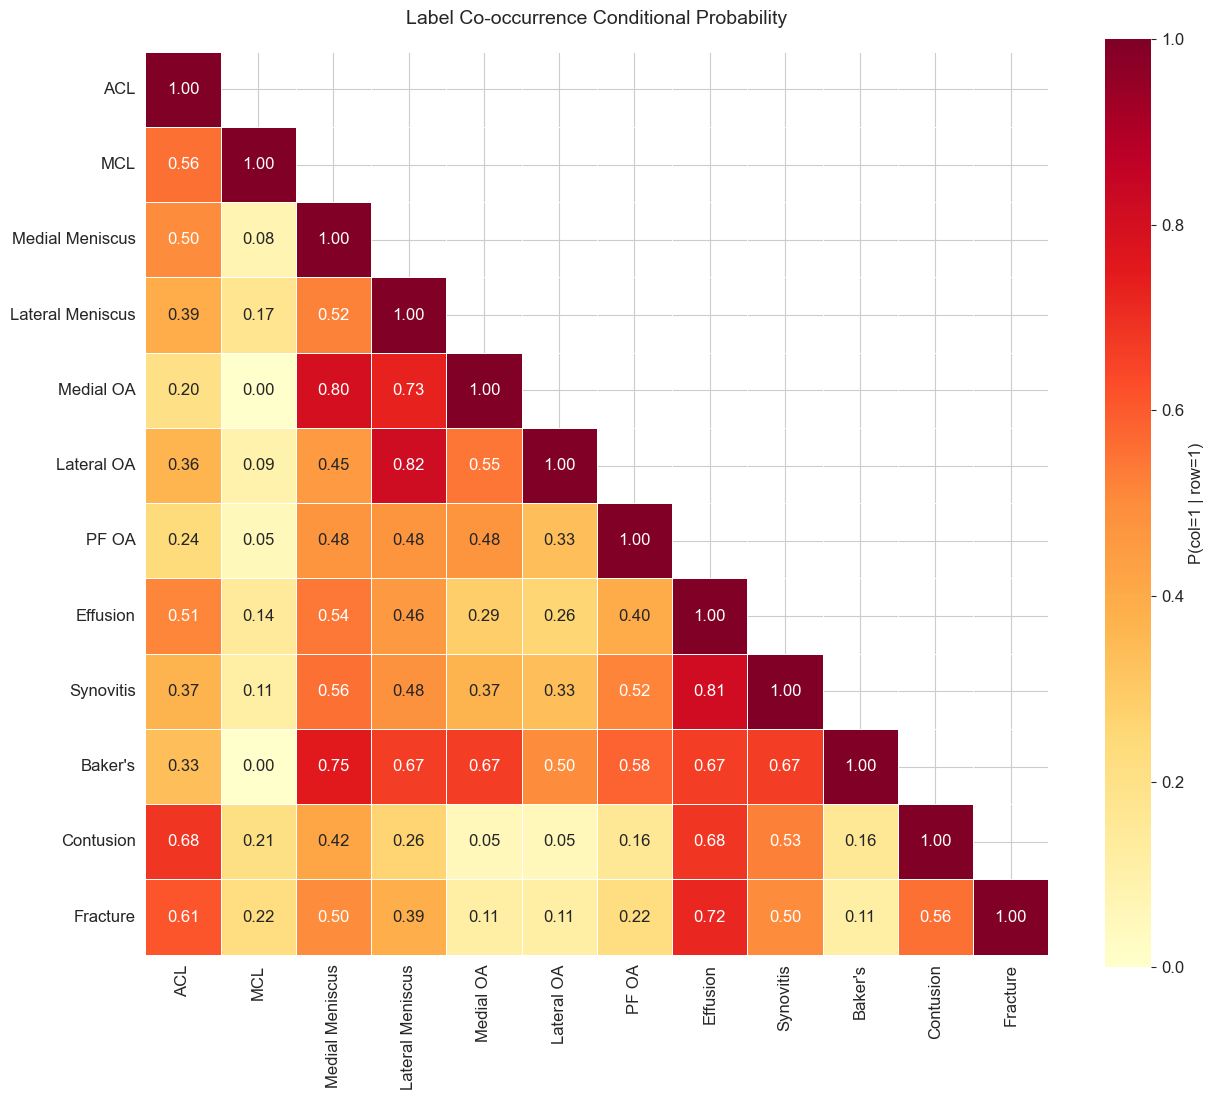

In [35]:
# 共现条件概率：P(label_j=1 | label_i=1)
cooccur_count = pd.DataFrame(
    np.dot(train[TARGET_COLS].T, train[TARGET_COLS].values),
    index=TARGET_COLS, columns=TARGET_COLS
)
label_support = np.diag(cooccur_count.values)
cooccur_prob = cooccur_count / label_support[:, np.newaxis]

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(cooccur_prob, dtype=bool), k=1)
sns.heatmap(
    cooccur_prob,
    annot=True, fmt='.2f', cmap='YlOrRd',
    mask=mask, vmin=0, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'P(col=1 | row=1)'},
    ax=ax
)
ax.set_title('Label Co-occurrence Conditional Probability', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
# 按 Jaccard 系数排序的 Top 共现对
pairs = []
for i, li in enumerate(TARGET_COLS):
    for j, lj in enumerate(TARGET_COLS):
        if i < j:
            pairs.append({
                'Label A': li, 'Label B': lj,
                'P(A|B)': round(cooccur_prob.iloc[j, i], 3),
                'P(B|A)': round(cooccur_prob.iloc[i, j], 3),
                'Jaccard': round(
                    cooccur_count.iloc[i, j] / (
                        cooccur_count.iloc[i, i]
                        + cooccur_count.iloc[j, j]
                        - cooccur_count.iloc[i, j]
                    ), 3
                )
            })

top_pairs = sorted(pairs, key=lambda x: x['Jaccard'], reverse=True)[:10]
print('Top 10 共现标签对（按 Jaccard 排序）:')
for p in top_pairs:
    print(f"  {p['Label A']:20s} -- {p['Label B']:20s}"
          f"  Jacc={p['Jaccard']:.3f}"
          f"  P(A|B)={p['P(A|B)']:.3f}"
          f"  P(B|A)={p['P(B|A)']:.3f}")


Top 10 共现标签对（按 Jaccard 排序）:
  Effusion             -- Synovitis             Jacc=0.550  P(A|B)=0.815  P(B|A)=0.629
  Medial Meniscus      -- Effusion              Jacc=0.452  P(A|B)=0.543  P(B|A)=0.731
  ACL                  -- Effusion              Jacc=0.439  P(A|B)=0.514  P(B|A)=0.750
  ACL                  -- Contusion             Jacc=0.433  P(A|B)=0.684  P(B|A)=0.542
  Medial OA            -- Baker's               Jacc=0.421  P(A|B)=0.667  P(B|A)=0.533
  Medial Meniscus      -- Medial OA             Jacc=0.414  P(A|B)=0.800  P(B|A)=0.462
  PF OA                -- Synovitis             Jacc=0.412  P(A|B)=0.519  P(B|A)=0.667
  Lateral Meniscus     -- Medial OA             Jacc=0.407  P(A|B)=0.733  P(B|A)=0.478
  Medial Meniscus      -- Synovitis             Jacc=0.395  P(A|B)=0.556  P(B|A)=0.577
  Medial OA            -- PF OA                 Jacc=0.385  P(A|B)=0.476  P(B|A)=0.667


### 对抽样的影响

- Jaccard > 0.8：选一个标签大概率覆盖另一个，不需要单独配额。
- Jaccard < 0.1：独立病症，各自需要单独配额。


## 6. 分析四：序列组成

> 来自 `train_series.csv`：每个 exam 有哪些 MRI 序列？
> 膝关节 MRI 的主要诊断序列通常是 **Sagittal PD FS**。


In [37]:
series['seq_type'] = series.apply(
    lambda r: f"{r['Anatomical_Plane']}_"
              f"{'FS' if r['Fat_Suppression']==1 else 'noFS'}_"
              f"{'Fluid' if r['Fluid_Sensitive']==1 else 'noFluid'}",
    axis=1
)

print(f'总序列数:     {len(series)}')
print(f'总 exam 数:   {series["StudyInstanceUID"].nunique()}')
print(f'每 exam 平均序列数: '
      f'{len(series) / series["StudyInstanceUID"].nunique():.1f}')
print()
print('=== 按解剖平面 ===')
print(series['Anatomical_Plane'].value_counts())
print()
print('=== 液体敏感 ===')
print(series['Fluid_Sensitive'].value_counts().rename({0: '否', 1: '是'}))
print()
print('=== 脂肪抑制 ===')
print(series['Fat_Suppression'].value_counts().rename({0: '否', 1: '是'}))


总序列数:     24371
总 exam 数:   4407
每 exam 平均序列数: 5.5

=== 按解剖平面 ===
Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

=== 液体敏感 ===
Fluid_Sensitive
是    14010
否    10361
Name: count, dtype: int64

=== 脂肪抑制 ===
Fat_Suppression
是    14010
否    10361
Name: count, dtype: int64


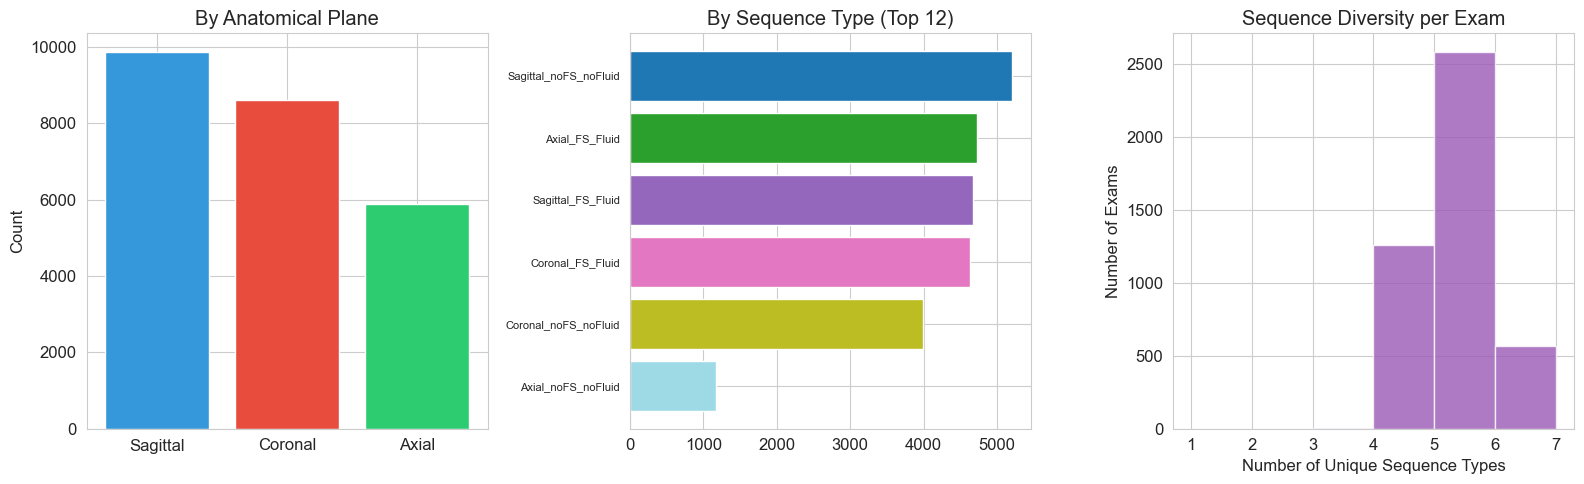

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
plane_counts = series['Anatomical_Plane'].value_counts()
ax.bar(plane_counts.index, plane_counts.values,
       color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('By Anatomical Plane')
ax.set_ylabel('Count')

ax = axes[1]
seq_type_counts = series['seq_type'].value_counts().head(12)
colors = plt.cm.tab20(np.linspace(0, 1, len(seq_type_counts)))
ax.barh(range(len(seq_type_counts)), seq_type_counts.values,
        color=colors, edgecolor='white')
ax.set_yticks(range(len(seq_type_counts)))
ax.set_yticklabels(seq_type_counts.index, fontsize=8)
ax.set_title('By Sequence Type (Top 12)')
ax.invert_yaxis()

ax = axes[2]
seq_variety = series.groupby('StudyInstanceUID')['seq_type'].nunique()
ax.hist(seq_variety, bins=range(1, int(seq_variety.max()) + 2),
        color='#9b59b6', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Unique Sequence Types')
ax.set_ylabel('Number of Exams')
ax.set_title('Sequence Diversity per Exam')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_series_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 存储估算（基于 CSV 元数据，无需 API）

> 膝关节 MRI 的典型 DICOM 参数：每序列 20–40 张切片，每张 ~250–500 KB。
> 用 series 表已有信息即可估算，不需要遍历 Kaggle 文件列表。


In [39]:
# 基于 series 表 + 典型参数估算
# 膝关节 MRI: Sagittal ~30 slices, Axial ~25, Coronal ~22（典型值）
PLANE_SLICE_EST = {'Sagittal': 30, 'Axial': 25, 'Coronal': 22}
DICOM_SIZE_KB = 350  # 典型膝关节 DICOM 文件大小

# 按 exam 汇总序列数
exam_series = series.groupby('StudyInstanceUID').agg(
    n_series=('SeriesInstanceUID', 'nunique'),
    planes=('Anatomical_Plane', lambda x: list(x))
).reset_index()

# 估算每个 exam 的切片数
def estimate_slices(planes):
    return sum(PLANE_SLICE_EST.get(p, 25) for p in planes)

exam_series['est_slices'] = exam_series['planes'].apply(estimate_slices)
exam_series['est_size_mb'] = (
    exam_series['est_slices'] * exam_series['n_series'] * DICOM_SIZE_KB / 1024
)

print('=== 全量数据估算 ===')
print(f'总 exam 数: {len(exam_series)}')
print(f'每 exam 平均序列数: {exam_series["n_series"].mean():.1f}')
print(f'每 exam 估算切片数: {exam_series["est_slices"].mean():.0f}')
print(f'总估算切片数: {exam_series["est_slices"].sum():.0f}')
print(f'全量估算存储: {exam_series["est_size_mb"].sum() / 1024:.1f} GB')
print()
print(f'=== Mini 集估算 (350 exams) ===')
print(f'Mini 集估算切片: {exam_series["est_slices"].mean() * 350:.0f}')
mini_est_gb = exam_series['est_size_mb'].mean() * 350 / 1024
print(f'Mini 集估算存储: ~{mini_est_gb:.1f} GB')
print()
print(f'=== RTX 5060 8GB 显存评估 ===')
print(f'按 350 exams × ~{exam_series["est_slices"].mean():.0f} slices ×')
print(f'  3 平面 × 224×224×3 uint8 = ~{350 * exam_series["est_slices"].mean() * 3 * 224 * 224 * 3 / 1024**3:.1f} GB 原始')
print(f'  实际可分批加载到内存，硬盘需求 ~{mini_est_gb:.1f} GB，完全可行')


=== 全量数据估算 ===
总 exam 数: 4407
每 exam 平均序列数: 5.5
每 exam 估算切片数: 144
总估算切片数: 632768
全量估算存储: 1239.9 GB

=== Mini 集估算 (350 exams) ===
Mini 集估算切片: 50254
Mini 集估算存储: ~98.5 GB

=== RTX 5060 8GB 显存评估 ===
按 350 exams × ~144 slices ×
  3 平面 × 224×224×3 uint8 = ~21.1 GB 原始
  实际可分批加载到内存，硬盘需求 ~98.5 GB，完全可行


## 8. Mini 集抽样策略

> 所有标签 < 1% 的情况下，策略从"分层抽样"调整为
> **"正样本全集 + 正常样本补足"**。


In [40]:
print('=' * 60)
print('Mini Dataset Sampling Strategy')
print('=' * 60)

print(f'\n全量数据集: {len(train)} exams')

positive_mask = train[TARGET_COLS].sum(axis=1) > 0
n_pos_union = positive_mask.sum()
n_neg = (~positive_mask).sum()
print(f'有 >=1 种异常的 exam: {n_pos_union}')
print(f'完全正常的 exam:      {n_neg}')

print(f'\n--- 逐标签覆盖分析 ---')
for col in TARGET_COLS:
    n_pos = train[col].sum()
    pct = n_pos / len(train) * 100
    exp_random = pct / 100 * 350
    if n_pos < 30:
        strategy = f'!! 必须取全部 {n_pos} 例'
    elif exp_random < 10:
        strategy = '需要配额 >= 10'
    else:
        strategy = '随机抽样即可'
    print(f'  {col:20s}: 共 {n_pos:4d} 例 ({pct:5.2f}%)'
          f' | 随机期望={exp_random:4.1f} | {strategy}')

print(f'\n--- 主力序列 ---')
prio = series[
    (series['Anatomical_Plane'] == 'Sagittal')
    & (series['Fat_Suppression'] == 1)
    & (series['Fluid_Sensitive'] == 1)
]
print(f'Sagittal + FS + Fluid: {len(prio)} 条序列')
print(f'覆盖 {prio["StudyInstanceUID"].nunique()} 个 exam')


Mini Dataset Sampling Strategy

全量数据集: 4407 exams
有 >=1 种异常的 exam: 58
完全正常的 exam:      4349

--- 逐标签覆盖分析 ---
  ACL                 : 共   24 例 ( 0.54%) | 随机期望= 1.9 | !! 必须取全部 24 例
  MCL                 : 共    9 例 ( 0.20%) | 随机期望= 0.7 | !! 必须取全部 9 例
  Medial Meniscus     : 共   26 例 ( 0.59%) | 随机期望= 2.1 | !! 必须取全部 26 例
  Lateral Meniscus    : 共   23 例 ( 0.52%) | 随机期望= 1.8 | !! 必须取全部 23 例
  Medial OA           : 共   15 例 ( 0.34%) | 随机期望= 1.2 | !! 必须取全部 15 例
  Lateral OA          : 共   11 例 ( 0.25%) | 随机期望= 0.9 | !! 必须取全部 11 例
  PF OA               : 共   21 例 ( 0.48%) | 随机期望= 1.7 | !! 必须取全部 21 例
  Effusion            : 共   35 例 ( 0.79%) | 随机期望= 2.8 | 需要配额 >= 10
  Synovitis           : 共   27 例 ( 0.61%) | 随机期望= 2.1 | !! 必须取全部 27 例
  Baker's             : 共   12 例 ( 0.27%) | 随机期望= 1.0 | !! 必须取全部 12 例
  Contusion           : 共   19 例 ( 0.43%) | 随机期望= 1.5 | !! 必须取全部 19 例
  Fracture            : 共   18 例 ( 0.41%) | 随机期望= 1.4 | !! 必须取全部 18 例

--- 主力序列 ---
Sagittal + FS + Fluid: 4667 条序列
覆盖 4150 个

In [41]:
print('=' * 60)
print('推荐策略')
print('=' * 60)

must_take_all = [(col, train[col].sum())
                 for col in TARGET_COLS if train[col].sum() < 30]
print(f'\n总正样本 < 30 的标签（{len(must_take_all)} 个）:')
for name, n in must_take_all:
    print(f'  {name}: 仅 {n} 例 — 全部纳入 Mini 集')

print(f'\nMini 集组成:')
print(f'  全部异常 exam（并集）:     {n_pos_union}')
rec_neg = max(150, 350 - n_pos_union)
print(f'  正常 exam（随机抽样）:     {rec_neg}')
print(f'  Mini 集总规模:             {n_pos_union + rec_neg}')
print(f'\n优势: 每个罕见标签的所有正样本都在 Mini 集中')
print(f'局限: per-class AUC 不稳定（正样本太少）；'
      f' Mini 集主要用于管线验证')
print(f'\n下一步: 02_stratified_sampling.ipynb')


推荐策略

总正样本 < 30 的标签（11 个）:
  ACL: 仅 24 例 — 全部纳入 Mini 集
  MCL: 仅 9 例 — 全部纳入 Mini 集
  Medial Meniscus: 仅 26 例 — 全部纳入 Mini 集
  Lateral Meniscus: 仅 23 例 — 全部纳入 Mini 集
  Medial OA: 仅 15 例 — 全部纳入 Mini 集
  Lateral OA: 仅 11 例 — 全部纳入 Mini 集
  PF OA: 仅 21 例 — 全部纳入 Mini 集
  Synovitis: 仅 27 例 — 全部纳入 Mini 集
  Baker's: 仅 12 例 — 全部纳入 Mini 集
  Contusion: 仅 19 例 — 全部纳入 Mini 集
  Fracture: 仅 18 例 — 全部纳入 Mini 集

Mini 集组成:
  全部异常 exam（并集）:     58
  正常 exam（随机抽样）:     292
  Mini 集总规模:             350

优势: 每个罕见标签的所有正样本都在 Mini 集中
局限: per-class AUC 不稳定（正样本太少）； Mini 集主要用于管线验证

下一步: 02_stratified_sampling.ipynb


## 9. 后续步骤

1. ✅ 标签分布分析（本 notebook）
2. ⬜ 提取全部正样本 exam ID + 补充负样本（`02_stratified_sampling.ipynb`）
3. ⬜ 仅下载选中 exam 的主力 DICOM 序列
4. ⬜ Mini 集验证（标签分布偏差、DICOM 可读性）
5. ⬜ 开始 2D baseline 训练
